# Table of contents

* **Introduction**
* **Objective**
* **Recurrent Neural Networks (RNNs) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
    * Model Architecture and Model Building (PyTorch)
    * Model Training
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

Time series forecasting is a specialized area of machine learning concerned with predicting future values based on historically observed data. This project utilizes a Recurrent Neural Network (RNN) to model the time-dependent sequence of stock prices (specifically Open, Close, High, Low, and Volume) for a single asset. The core concept behind using an RNN is its inherent ability to process sequences by maintaining a hidden state that encapsulates information from previous time steps. This allows the network to learn complex temporal dependencies, making it suitable for capturing patterns like trends and seasonality in financial data.

# Objective

The primary objective is to build and evaluate a PyTorch RNN model capable of performing univariate-to-multivariate sequence prediction. The model must take a fixed-length window of historical stock features as input and output the forecast for the next day's five financial metrics. The development focuses on creating a robust and reliable pipeline that correctly handles the chronological nature of the data, thereby ensuring the model's performance on future, unseen market activity is genuinely assessed.

# Recurrent Neural Networks (RNNs) Foundations

Recurrent Neural Networks (RNNs) are a class of artificial neural networks specifically designed to process sequential data, such as time series, speech, and text. Unlike standard feedforward networks, which treat each input independently, RNNs possess an internal "memory" that allows information from previous steps to persist and influence the processing of the current input. This characteristic makes them the foundational architecture for sequence modeling.

**Core Principles**

**1. Sequential Processing and Recurrence**

The defining feature of an RNN is its recurrent loop. At any time step $t$, the network receives two inputs: the current data point in the sequence, $\mathbf{x}_t$, and the hidden state from the previous time step, $\mathbf{h}_{t-1}$.

The new hidden state, $\mathbf{h}_t$, is calculated using a non-linear activation function (like $\tanh$) and a set of shared weights, $W_{xh}$ for the input and $W_{hh}$ for the recurrent connection:


$$\mathbf{h}_t = f(W_{xh}\mathbf{x}_t + W_{hh}\mathbf{h}_{t-1} + \mathbf{b}_h)$$

**2. Weight Sharing Across Time**

A crucial concept is weight sharing. The same weight matrices ($W_{xh}$, $W_{hh}$, and the output weight $W_{hy}$) are used for every time step in the sequence. This greatly reduces the number of parameters the network must learn and allows the model to generalize across the entire sequence length, learning a single function that processes all temporal steps.

**3. Backpropagation Through Time (BPTT)**

Training an RNN involves an adaptation of the standard backpropagation algorithm called Backpropagation Through Time (BPTT). The recurrence relation is unrolled over the entire sequence, treating the network at each time step as a separate layer in a deep feedforward network. Gradients are then calculated and propagated backward through this unrolled structure.

**Inherent Challenges (The Gradient Problem)**

While powerful for short sequences, the vanilla RNN architecture suffers from fundamental problems during BPTT:

**1. Vanishing Gradient Problem**

As the gradient is repeatedly multiplied by the weight matrices through many time steps (layers), the value of the gradient can shrink exponentially towards zero. This makes the gradient contribution from distant past inputs (early steps in the sequence) negligible. Consequently, the network struggles to learn long-term dependencies—a critical limitation for tasks like complex language modeling or predicting long financial trends.

2. Exploding Gradient Problem

Conversely, if the weights are large, the gradient can grow exponentially, leading to an exploding gradient. This results in numerical instability, causing large updates to the model parameters, which renders the training unstable or ineffective. This is typically addressed using gradient clipping, a technique that scales down the gradients if they exceed a certain threshold.

**Solutions and Successors**

The severe limitations of the vanilla RNN led to the development of more sophisticated architectures that include mechanisms for regulating the flow of information:
- Long Short-Term Memory (LSTM): Introduces specialized gates (input, forget, and output) and a cell state to explicitly control which information is stored, updated, or discarded. LSTMs effectively solve the vanishing gradient problem and are the standard choice for most sequence tasks.
- Gated Recurrent Unit (GRU): A simplified version of the LSTM that merges the cell state and hidden state, using only two gates (reset and update). GRUs are often computationally less expensive and perform comparably to LSTMs on many datasets.

The general RNN structure serves as the conceptual basis, but modern time series and sequence modeling almost exclusively rely on LSTMs or GRUs due to their superior ability to capture information over long spans of time.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Field Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">date</td>
    <td class="tg-7zrl">The date range for each data entry. This appears to be a combined string of start and end dates.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">DateTimeCount</td>
    <td class="tg-7zrl">The count of DateTime entries within the specified date range.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">symbol</td>
    <td class="tg-7zrl">An identifier or code, possibly for a financial instrument or category.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">open</td>
    <td class="tg-7zrl">The opening price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">close</td>
    <td class="tg-7zrl">The closing price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">low</td>
    <td class="tg-7zrl">The lowest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">high</td>
    <td class="tg-7zrl">The highest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">volume</td>
    <td class="tg-7zrl">The trading volume (number of units traded) within a given period.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/dgawlik/nyse)**

# Pipeline Overview

The project follows a standard, rigorous machine learning pipeline to ensure data integrity and model reliability:
- Data Preparation: Load the raw data, chronologically split it into training and testing sets, and isolate the target stock.
- Preprocessing: Apply MinMaxScaler normalization to all price and volume features using parameters derived only from the training set.
- Sequence Generation: Transform the preprocessed data into overlapping sequences, defining the input look-back window and the single-step-ahead target.
- Model Training: Implement the custom RNN in PyTorch and train it using the Mean Squared Error (MSE) loss function, incorporating a validation set for monitoring and early stopping.
- Evaluation: Assess the final model using both the scaled MSE loss on the test set and real-world metrics like RMSE and Directional Accuracy on the inverse-transformed data.

# Approach

**Preprocessing Pipeline Approach**

**Chronological Splitting and Scaling**

To prevent data leakage, the dataset is first divided chronologically, reserving the latest $20\%$ of the data for the test set. This simulates real-world conditions where the model forecasts genuinely future prices. Feature scaling is then applied using the MinMaxScaler. This process maps the raw price and volume values into a small, consistent range (typically $[0, 1]$), which is essential for stabilizing and accelerating the convergence of the gradient descent optimization process used in neural network training. Critically, the scaler is fitted exclusively on the training data and then used to transform all three sets (train, validation, and test), maintaining the integrity of the data partitions.

**Sequence Generation**

For the RNN to learn temporal patterns, the sequential nature of the data must be explicitly captured. This is achieved through a sliding window technique. A fixed sequence length (e.g., 30 days) defines the input, $X$, while the next single day's values form the target, $y$. This process converts the linear time series into three-dimensional sequences ready for the recurrent layers. The original training set sequences are further subdivided into training and validation sets (e.g., $80\%$ and $20\%$) to monitor for overfitting during training.

**Model Training Approach**

**Vanilla RNN Architecture**

The model employs a vanilla Recurrent Neural Network (RNN), which contains recurrent connections that pass information from the current time step's computation to the next. The architecture typically includes stacked RNN layers to increase modeling capacity, followed by a Dropout layer to regularize the network and prevent excessive reliance on specific features. A final Linear layer maps the RNN's output (the last hidden state of the sequence) to the desired prediction vector size (five features in this case).

**Loss and Optimization**

The model is optimized using the Adam optimizer, known for its adaptive learning rate capabilities, minimizing the Mean Squared Error (MSE) loss. MSE is the standard loss function for regression tasks, penalizing larger prediction errors more heavily. The training process incorporates a crucial technique: early stopping. The validation set's loss is monitored, and training halts if the validation loss fails to decrease for a set number of epochs (patience). This prevents the model from overfitting to the training data and ensures the final saved weights generalize better to unseen data.

**Model Evaluation Approach**

**Performance Metrics**

Evaluation is performed on the completely unseen test set to assess the true generalization capability of the model.

- Final Test Loss (MSE): The loss is computed on the scaled test data, providing a direct comparison to the loss achieved during training and validation.
- Root Mean Squared Error (RMSE): Predictions are inverse-transformed back to the original dollar scale to calculate the RMSE, which measures the average magnitude of the forecast error in interpretable dollar units.
- Directional Accuracy: This crucial financial metric assesses the percentage of time the model correctly predicts the direction of the daily price movement (i.e., whether the Close price is greater than the Open price).

**Visualization of Predictions**

For a comprehensive assessment, predictions for the training, validation, and test sets are generated in chronological order. The Open Price feature is selected for visualization. Two plots are generated: one showing the full timeline (actual vs. predicted for all three sets) and a zoomed plot focusing only on the test set. This visualization allows for a qualitative inspection of the model's tracking ability, lag, and smoothness, providing visual evidence of its generalization performance.

# Setup Environments

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import math
import sklearn
import sklearn.preprocessing
import datetime
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore", category=FutureWarning, module='seaborn._oldcore')

2026-03-25 17:59:24.565477: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774461564.779312      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774461564.840915      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Data Loading

The process begins with loading the New York Stock Exchange (NYSE) data, which contains various features for multiple stocks over time. The primary challenge in time series analysis is maintaining the chronological integrity of the data to accurately simulate real-world forecasting.

In [2]:
df = pd.read_csv('/kaggle/input/nyse/prices-split-adjusted.csv')
df.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


**Train and Test Split**

The dataset is initially loaded, and its sheer size necessitates an efficient chronological split into training (80%) and testing (20%) subsets. The data must be sorted strictly by the $\mathbf{date}$ column before splitting. This non-randomized partitioning ensures the training process uses only historical information, and the test set represents the genuinely unseen future data. Violating this constraint would lead to data leakage, resulting in an overly optimistic and unreliable model evaluation. The shapes of the resulting subsets confirm the non-random, time-based division.

In [3]:
df = df.sort_values(by='date', ascending=True).reset_index(drop=True)

test_size_ratio = 0.2 
split_point = int(len(df) * (1 - test_size_ratio))

train = df.iloc[:split_point].copy()
test = df.iloc[split_point:].copy()

print("\nData split chronologically by 'date' column:")
print(f"Train DataFrame shape: {train.shape}")
print(f"Test DataFrame shape: {test.shape}")


Data split chronologically by 'date' column:
Train DataFrame shape: (681011, 7)
Test DataFrame shape: (170253, 7)


In [4]:
train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)

**Stock Selection and Filtering**

For concentrated, single-series modeling, the data is filtered to isolate only the records corresponding to the target stock, $\mathbf{EQIX}$. Focusing on a single ticker simplifies the initial multivariate modeling problem, ensuring that the recurrent model learns the specific temporal patterns and volatility characteristics unique to that equity.

In [5]:
train = train[train.symbol == 'EQIX'].copy()
test = test[test.symbol == 'EQIX'].copy()

train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)
train

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0
...,...,...,...,...,...,...,...
1417,2015-08-20,EQIX,284.220001,279.959991,279.920013,284.649994,568700.0
1418,2015-08-21,EQIX,277.160004,271.309998,271.309998,279.790009,1271900.0
1419,2015-08-24,EQIX,260.000000,255.529999,251.000000,267.089996,1306700.0
1420,2015-08-25,EQIX,260.309998,251.110001,250.860001,263.670013,1294200.0


# Exploratory Data Analysis (EDA)

Exploratory analysis provides critical insights into data trends, volatility, and the internal relationships between features, informing the subsequent feature engineering and model design phases.

**Basic Statistics**

In [6]:
train.head()

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1422 entries, 0 to 1421
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1422 non-null   object 
 1   symbol  1422 non-null   object 
 2   open    1422 non-null   float64
 3   close   1422 non-null   float64
 4   low     1422 non-null   float64
 5   high    1422 non-null   float64
 6   volume  1422 non-null   float64
dtypes: float64(5), object(2)
memory usage: 77.9+ KB


In [8]:
train.describe()

,open,close,low,high,volume
count,1422.000000,1422.000000,1422.000000,1422.000000,1.422000e+03
mean,160.671779,160.734803,158.748868,162.544423,9.128723e+05
std,57.769144,57.761722,57.255626,58.169847,1.064773e+06
min,71.750000,70.339996,69.419998,74.510002,1.524000e+05
25%,98.382502,98.502500,97.042500,99.649997,5.338000e+05
50%,173.614998,173.385002,170.770004,176.120003,7.309500e+05
75%,210.034996,210.097504,208.022495,212.072502,1.040200e+06
max,286.130005,287.420013,283.980011,288.500000,3.057420e+07


**Features Trends and Stationarity**

The price features ($\mathbf{open, close, low, high}$) display a strong upward, non-stationary trend over the observation period, reflecting significant capital appreciation. The lines remain tightly grouped, indicating low intraday volatility in most periods. The $\mathbf{volume}$ feature, however, is characterized by large, intermittent spikes, suggesting irregular trading activity driven by news or corporate events. Time series models must account for these non-stationary trends and volatility bursts.

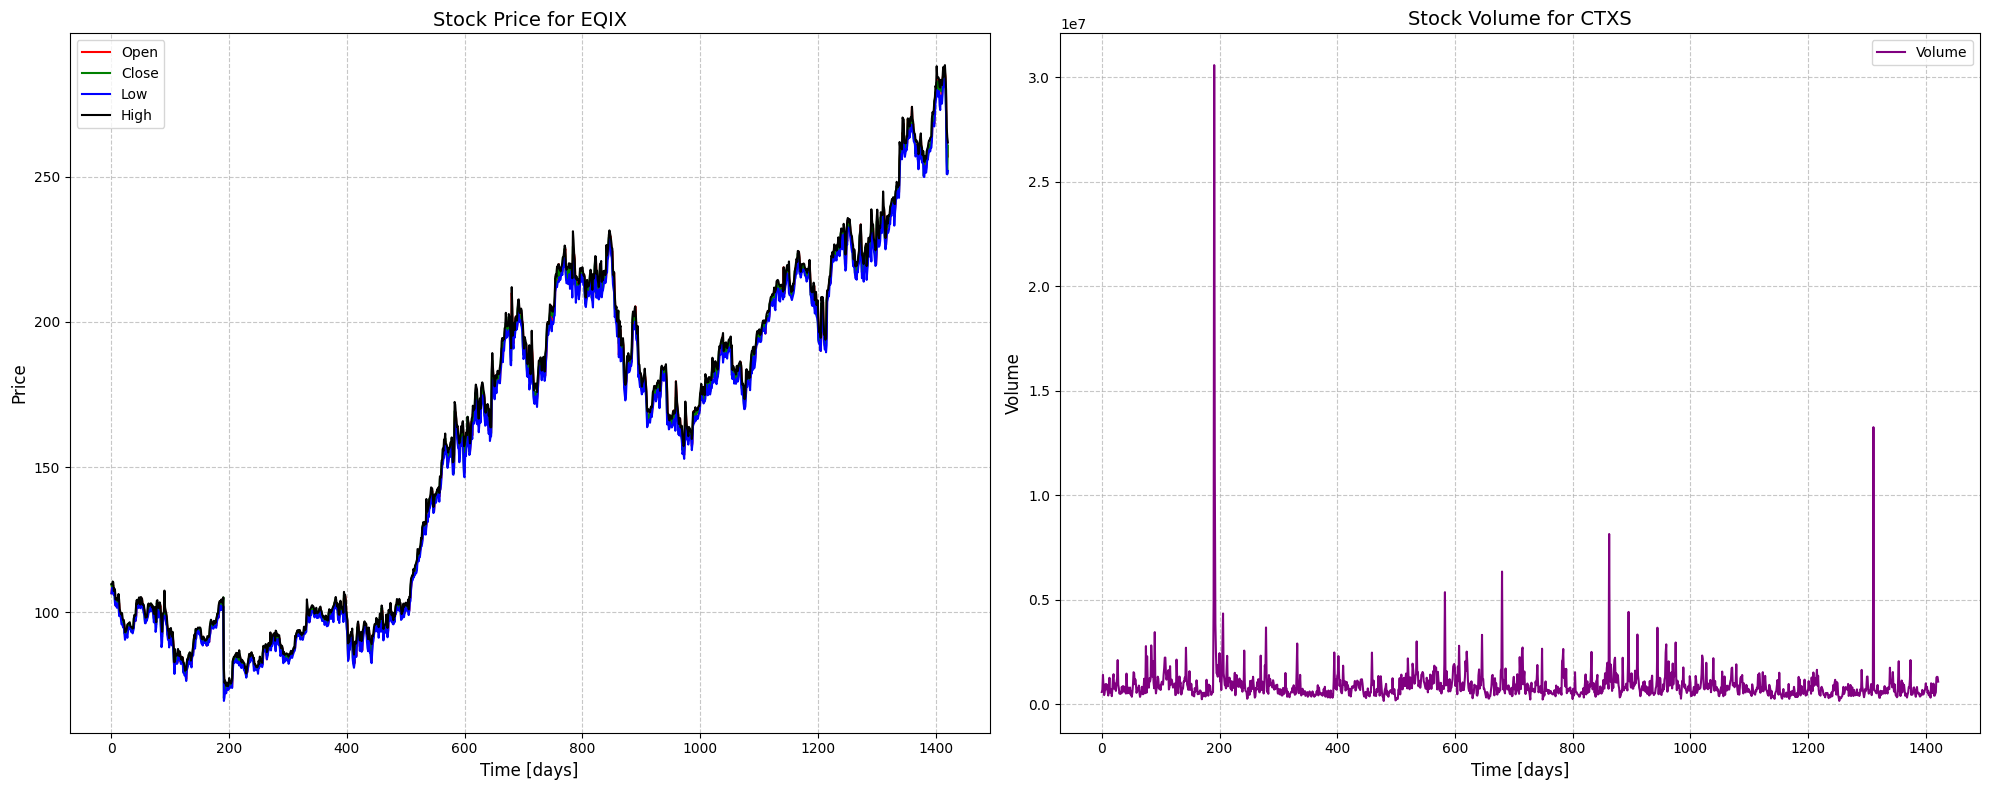

In [9]:
train['time_idx'] = range(len(train))

ctxs_data = train[train.symbol == 'EQIX']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.lineplot(x='time_idx', y='open', data=ctxs_data, color='red', label='Open', ax=axes[0])
sns.lineplot(x='time_idx', y='close', data=ctxs_data, color='green', label='Close', ax=axes[0])
sns.lineplot(x='time_idx', y='low', data=ctxs_data, color='blue', label='Low', ax=axes[0])
sns.lineplot(x='time_idx', y='high', data=ctxs_data, color='black', label='High', ax=axes[0])

axes[0].set_title('Stock Price for EQIX', fontsize=14)
axes[0].set_xlabel('Time [days]', fontsize=12)
axes[0].set_ylabel('Price', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(x='time_idx', y='volume', data=ctxs_data, color='purple', label='Volume', ax=axes[1])

axes[1].set_title('Stock Volume for CTXS', fontsize=14)
axes[1].set_xlabel('Time [days]', fontsize=12)
axes[1].set_ylabel('Volume', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Correlation Analysis**

Feature correlation analysis, presented in the heatmap, reveals critical statistical relationships within the time series data.

In [10]:
train = train.drop(columns=['symbol'])
test = test.drop(columns=['symbol'])
train

,date,open,close,low,high,volume,time_idx
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4
...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420


In [11]:
train['date'] = pd.to_datetime(train['date'])

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train

,date,open,close,low,high,volume,time_idx,year,month,day
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0,2010,1,4
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1,2010,1,5
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2,2010,1,6
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3,2010,1,7
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4,2010,1,8
...,...,...,...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417,2015,8,20
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418,2015,8,21
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419,2015,8,24
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420,2015,8,25


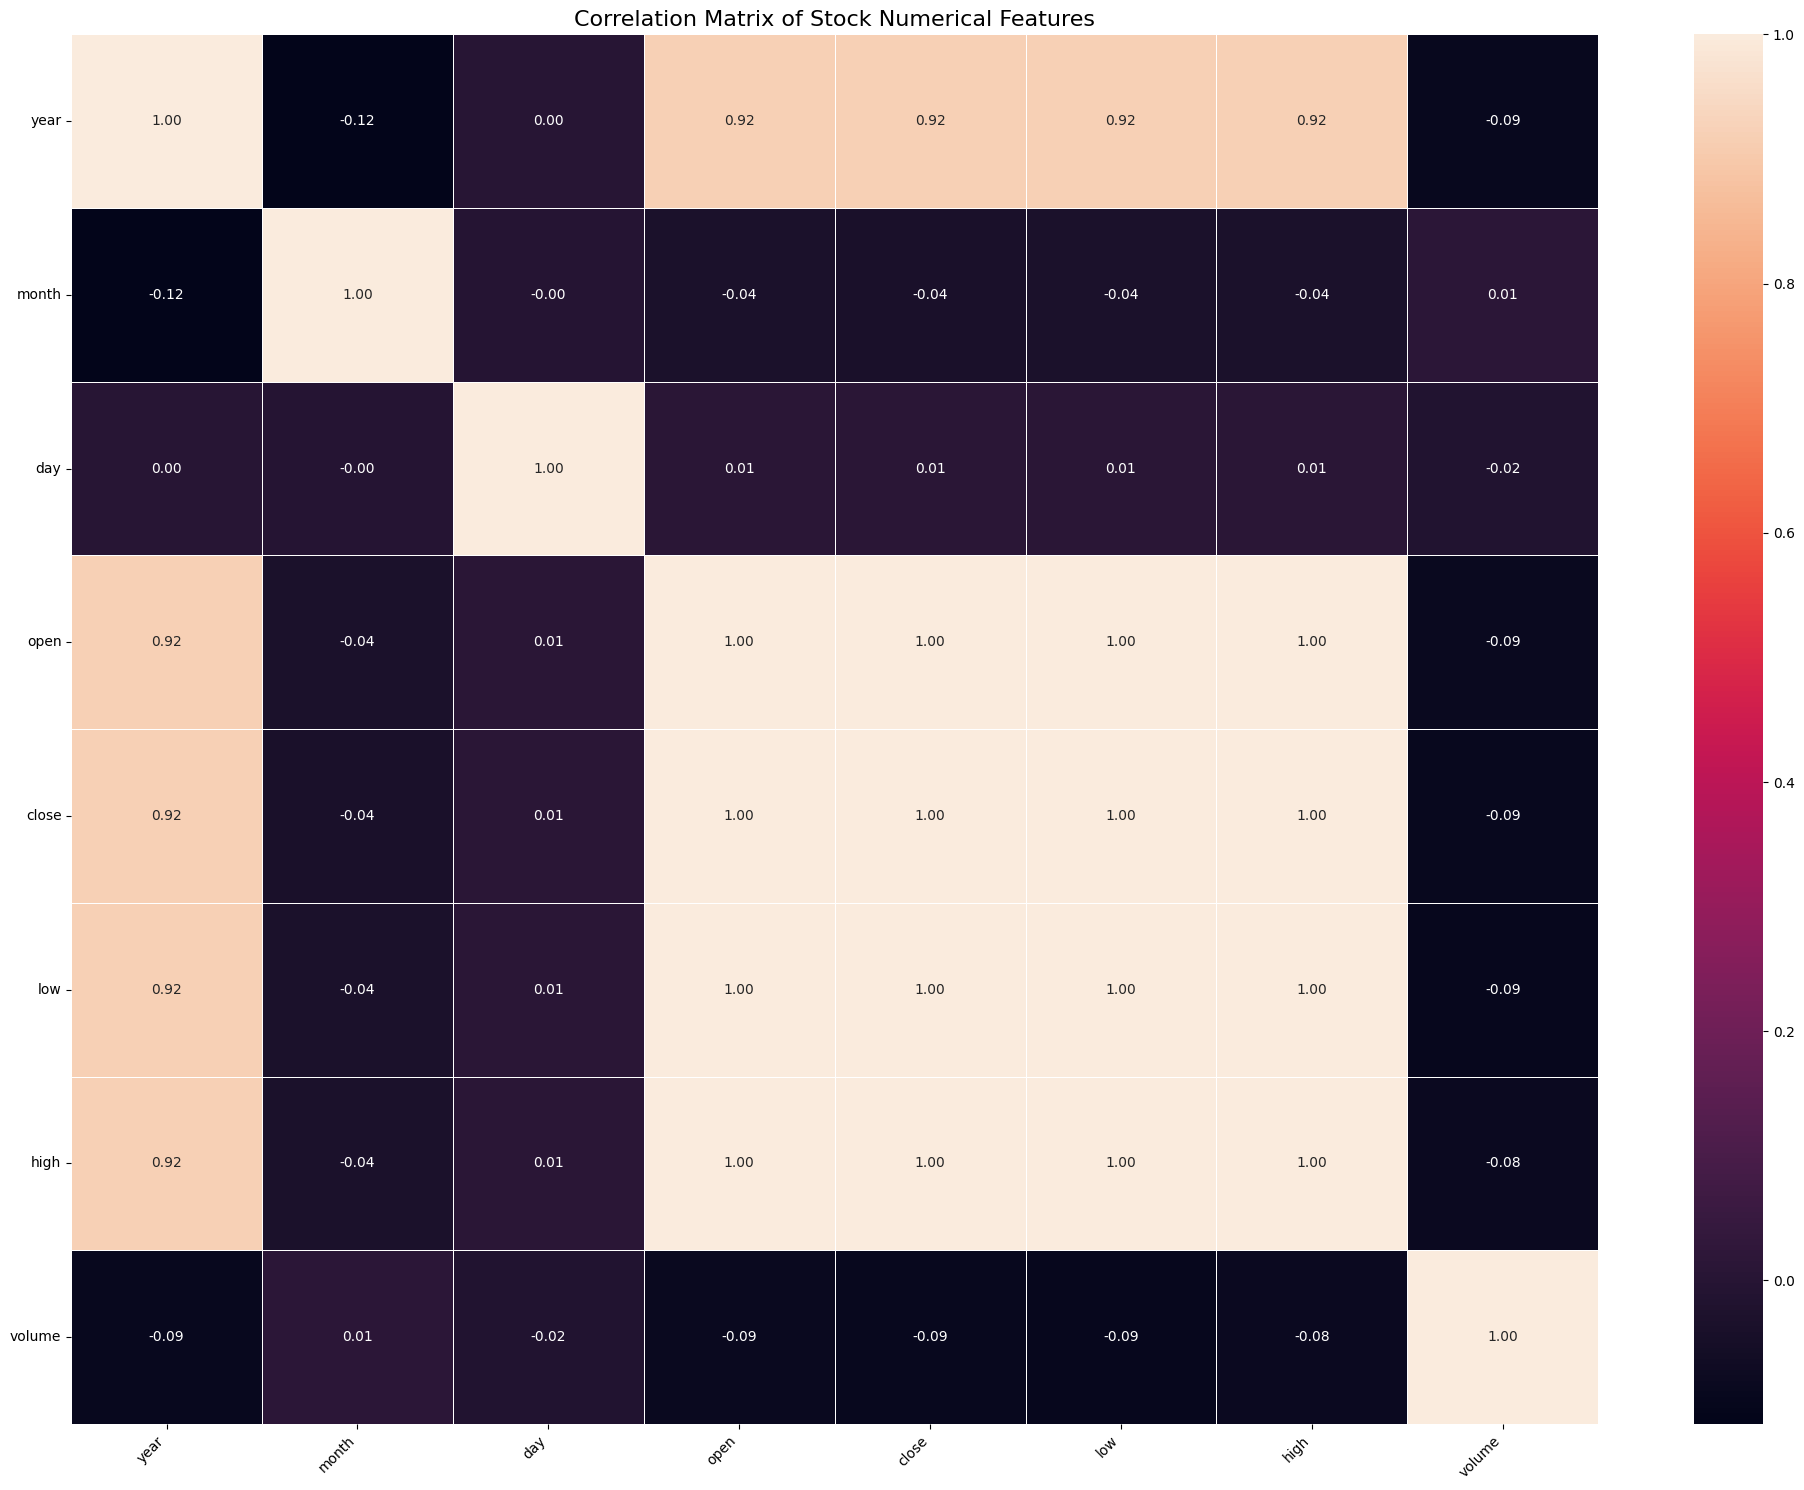

In [12]:
numerical_cols = ['year','month','day', 'open', 'close', 'low', 'high', 'volume']

correlation_matrix = train[numerical_cols].corr(method='pearson')

plt.figure(figsize=(20, 15))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='rocket',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Stock Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Correlation Analysis Interpretation**

- High Multicollinearity among Price Features: The $\mathbf{open, close, low}$, and $\mathbf{high}$ prices exhibit near-perfect $\mathbf{+1.00}$ correlation coefficients. This is expected in financial data, as the day's prices are tightly bound. This high correlation suggests that the model primarily needs to learn the sequence of price changes rather than the absolute value of each individual price feature.
- Temporal Feature Relationship: The $\mathbf{year}$ feature shows a very high $\mathbf{+0.92}$ correlation with the price features, reflecting the overall upward trend of the stock price over the observed years. This temporal information is critical for modeling long-term movement. $\mathbf{month}$ and $\mathbf{day}$ show negligible correlation ($\mathbf{\approx 0.00}$) with the price features, indicating they provide little linear predictive value on their own but may capture cyclical monthly or weekly effects when processed by a non-linear network like the RNN.
- Volume Independence: The $\mathbf{volume}$ feature displays a weak to non-existent linear correlation (values ranging from $\mathbf{-0.09}$ to $\mathbf{0.01}$) with all price and temporal features. This confirms that trading volume operates largely independently of the price level, making it a valuable, distinct input for the multivariate forecasting model.

# Features Engineering

The goal of this phase is to refine the features, ensuring the RNN receives clean, scaled, and chronologically consistent inputs.

**Feature Selection (Noise Reduction)**

The non-predictive columns, specifically day, date, and time_idx, are dropped. Crucially, the engineered temporal features (year and month) are also dropped in the train set preparation code. Therefore, the final feature set for the RNN input consists only of the 5 financial metrics: open, close, low, high, and volume. This results in a consistent feature vector size of 5. This selection provides the RNN model solely with market data. 

**Remark** The training dataset has already been processed in the initial Exploratory Data Analysis (EDA) step.

In [37]:
train = train.drop(columns=['day','date','month','year', 'time_idx'])
test = test.drop(columns=['date'])
train

,open,close,low,high,volume
0,106.519997,109.559998,106.510002,109.620003,576300.0
1,109.589996,108.540001,108.379997,109.589996,681900.0
2,108.949997,109.529999,108.220001,110.570000,1397500.0
3,109.250000,107.290001,106.639999,110.349998,797200.0
4,106.800003,106.769997,105.900002,107.279999,432400.0
...,...,...,...,...,...
1417,284.220001,279.959991,279.920013,284.649994,568700.0
1418,277.160004,271.309998,271.309998,279.790009,1271900.0
1419,260.000000,255.529999,251.000000,267.089996,1306700.0
1420,260.309998,251.110001,250.860001,263.670013,1294200.0


**Data Normalization (Min-Max Scaling)**

**Normalization** is a mandatory step for training deep neural networks. Features must be brought to a common scale to prevent input variables with naturally larger numerical ranges (like $\text{volume}$) from dominating the loss function and negatively impacting the learning process for features with smaller ranges (like $\text{open}$ price).

**Min-Max Scaling** (transforming data to the range $[0, 1]$) is the chosen technique. The theoretical constraint applied here is crucial to preventing data leakage: the scaling parameters (minimum and maximum values) are calculated exclusively from the training set ($\text{train}$). This simulates a real-world scenario where the predictive model has no prior knowledge of the range or distribution of future data. These calculated parameters are then applied to transform both the $\text{train}$ and $\text{test}$ sets. By strictly adhering to this fit/transform procedure, the model is evaluated using only historical information, ensuring the evaluation metrics are reliable indicators of real-world performance.

In [ ]:
print("\n--- Applying Min-Max Scaling to Numerical Features ---")

numerical_cols = ['open', 'close', 'low', 'high', 'volume']
scaler = MinMaxScaler()

train[numerical_cols] = scaler.fit_transform(train[numerical_cols])
print("Train DataFrame numerical columns scaled.")

test[numerical_cols] = scaler.transform(test[numerical_cols])
print("Test DataFrame numerical columns transformed.")


--- Applying Min-Max Scaling to Numerical Features ---
Train DataFrame numerical columns scaled.
Test DataFrame numerical columns transformed.


**Sliding Window Transformation: Sequence Creation for Recurrent Networks**

Recurrent Neural Networks, including the LSTM, require input data to be structured as sequences or "time windows," not as independent, single-row observations.

The Sliding Window Technique is the standard approach for transforming a linear time series into a suitable 3D array for RNNs. The project uses a sequence length (`seq_len`) of 30 days. The concept is as follows: for any point in time $t$, the input sequence ($\mathbf{X}$) consists of the 30 days preceding the target date ($t-29$ to $t$). The corresponding target ($\mathbf{y}$) is the feature vector for the next single time step ($t+1$), specifically targeting only the 5 price columns. This process transforms the 2D feature data into the required 3D format: $(\text{Number of Samples}, \text{Sequence Length}, \text{Number of Features})$.

**Chronological Splitting of Sequences**

The sequence creation process respects the initial chronological split and also creates a validation set:

- Training Sequences: Sequences generated from the $\text{train}$ data are chronologically split, reserving $20%$ of the latest sequences for the $\mathbf{x}_{\text{valid}}$ and $\mathbf{y}_{\text{valid}}$ sets. This ensures the validation set represents the most recent historical patterns before the final test period.
- Test Sequences: A separate function generates sequences from the $\text{test}$ data. Since the test data is the dedicated future holdout, all sequences generated from it are used for the final evaluation $\mathbf{x}_{\text{test}}$ and $\mathbf{y}_{\text{test}}$.

The resulting shapes confirm the successful transformation. The input sequences ($\mathbf{x}_{\text{train}}, \mathbf{x}_{\text{valid}}, \mathbf{x}_{\text{test}}$) have the shape $\text{(N, 30, 5)}$, where 30 is the $\text{seq\_len}$ and 5 is the feature size. The single-step target predictions ($\mathbf{y}_{\text{train}}, \mathbf{y}_{\text{valid}}, \mathbf{y}_{\text{test}}$) have the shape $\text{(N, 5)}$.

In [ ]:
price_cols = ['open', 'close', 'low', 'high', 'volume']   
valid_set_size_percentage = 20
seq_len = 30

def create_sequences(df: pd.DataFrame,
                    seq_len: int,
                    valid_pct: int = 20):
    """
    Build (x_train, y_train, x_valid, y_valid) from a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Full training data (all columns).
    seq_len : int
        Number of past timesteps that form one input sample.
    valid_pct : int
        Percentage of *generated* sequences that go to validation.

    Returns
    -------
    tuple
        (x_train, y_train, x_valid, y_valid)
        * x_* : shape (samples, seq_len, n_features)
        * y_* : shape (samples, 5)   only the 5 price columns
    """

    data = df.values

    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)

    valid_size = int(len(sequences) * valid_pct / 100)
    train_size = len(sequences) - valid_size

    x_train = sequences[:train_size, :-1, :]
    x_valid = sequences[train_size:, :-1, :]

    price_idx = [df.columns.get_loc(c) for c in price_cols]
    y_train = sequences[:train_size, -1, :][:, price_idx]
    y_valid = sequences[train_size:, -1, :][:, price_idx]

    return x_train, y_train, x_valid, y_valid

def create_test_sequences(df: pd.DataFrame, seq_len: int):
    data = df.values
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)

    price_idx = [df.columns.get_loc(c) for c in price_cols]

    x_test = sequences[:, :-1, :]
    y_test = sequences[:, -1, :][:, price_idx]
    return x_test, y_test

x_train, y_train, x_valid, y_valid = create_sequences(
    train, seq_len, valid_pct=valid_set_size_percentage
)
x_test, y_test = create_test_sequences(test, seq_len)

print('x_train.shape = ',x_train.shape)
print('y_train.shape = ', y_train.shape)
print('x_valid.shape = ',x_valid.shape)
print('y_valid.shape = ', y_valid.shape)
print('x_test.shape = ', x_test.shape)
print('y_test.shape = ',y_test.shape)

x_train.shape =  (1114, 30, 5)
y_train.shape =  (1114, 5)
x_valid.shape =  (278, 30, 5)
y_valid.shape =  (278, 5)
x_test.shape =  (310, 30, 5)
y_test.shape =  (310, 5)


**PyTorch Tensor Conversion**

The final step involves converting the processed NumPy arrays into PyTorch Tensors (`torch.float32`). This conversion is essential because PyTorch models operate directly on tensors, and the floating-point type is necessary for the subsequent gradient calculations during the training phase. The data is now prepared and correctly dimensioned for use in the RNN model's `DataLoader`.

In [ ]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_valid_tensor = torch.tensor(x_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print(f"x_train_tensor shape: {x_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"x_valid_tensor shape: {x_valid_tensor.shape}")
print(f"y_valid_tensor shape: {y_valid_tensor.shape}")
print(f"x_test_tensor shape: {x_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")
print("="*40 + "\n")

x_train_tensor shape: torch.Size([1114, 30, 5])
y_train_tensor shape: torch.Size([1114, 5])
x_valid_tensor shape: torch.Size([278, 30, 5])
y_valid_tensor shape: torch.Size([278, 5])
x_test_tensor shape: torch.Size([310, 30, 5])
y_test_tensor shape: torch.Size([310, 5])



# Model Training

## Model Architecture and Model Building (PyTorch)

**Model Architecture and Initialization**

PyTorch Dataset and Data LoadersThe first step in the modeling phase is organizing the preprocessed, sequential data into a format PyTorch can efficiently handle. The TimeSeriesDataset custom class is created to encapsulate the input sequences ($\mathbf{X}$) and their corresponding target values ($\mathbf{y}$).

These datasets are then wrapped in DataLoaders, which manage batching and parallel data access. For the training set, `shuffle=True` is used to introduce stochasticity into the learning process, which helps the model generalize and prevents it from getting stuck in local minima. Crucially, the validation and test DataLoaders, and the separate plotting DataLoaders, maintain `shuffle=False` to preserve the chronological order of the time series, which is essential for accurate evaluation and visualization.

**Vanilla RNN Model Structure**

The core of the model is the TimeSeriesRNN class, which implements a basic Recurrent Neural Network. This architecture is composed of sequential layers designed for time-series forecasting:
- Layer Normalization (`nn.LayerNorm`): Applied to the input sequence features. Normalization within the network helps stabilize the hidden state dynamics of the RNN and accelerates convergence.
- Stacked RNN Layer: A vanilla RNN with 3 layers is used. Stacking multiple recurrent layers allows the network to learn progressively more abstract and complex temporal representations.
- Dropout (`nn.Dropout`): A dropout rate of 0.3 is applied to the recurrent layers and before the final linear layer. Dropout is a regularization technique that randomly sets a fraction of neurons to zero during training, preventing co-adaptation of neurons and reducing overfitting.
- Linear Layer: The output from the last time step of the final RNN layer is passed to a fully connected layer, which maps the internal hidden representation (size 128) to the required output size (5), corresponding to the predicted next-day stock features.

The model is configured to take input sequences with 5 features and outputs 5 predicted features.

**Model Training Approach**

**Optimization and Loss**

The model is optimized using the Adam optimizer, a robust method that dynamically adjusts the learning rate for each parameter. The loss is measured by the Mean Squared Error (MSE) loss, which is standard for regression tasks. It penalizes large errors heavily, driving the model toward accurate point estimates.

**Training Regularization Techniques**

To ensure the model converges efficiently and prevents overfitting to the training data, two advanced control mechanisms are implemented:
- Learning Rate Scheduler (`ReduceLROnPlateau`): This technique monitors the performance on the validation set (`val_loss`). If the validation loss fails to improve for a set number of epochs (`patience=6`), the learning rate is automatically reduced (`factor=0.5`). This helps the model escape plateaus in the loss landscape and achieve finer convergence near the optimal solution.
- Early Stopping: This is a crucial regularization technique in deep learning. It tracks the best validation loss achieved so far. If the validation loss fails to decrease for a prolonged period (`patience=18`), training is terminated early. This saves computational resources and, most importantly, prevents the model from continuing to learn noise and memorize the training data, restoring the model weights corresponding to the lowest validation loss.

**Training Dynamics**

The training loop alternates between the training phase (where gradients are calculated and weights are updated) and the validation phase (where loss is calculated without updating weights). This continuous monitoring of the validation loss guides both the learning rate scheduler and the early stopping mechanism, ensuring the final model is the one that generalizes best to unseen data.

In [ ]:
# DATASET & DATALOADER
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_dataset = TimeSeriesDataset(x_train_tensor, y_train_tensor)
val_dataset   = TimeSeriesDataset(x_valid_tensor, y_valid_tensor)
test_dataset  = TimeSeriesDataset(x_test_tensor,  y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# ordered loaders for plotting (no shuffle)
train_loader_plot = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader_plot   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader_plot  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Valid: {len(val_dataset)} | Test: {len(test_dataset)}")
print("="*50)


# VANILLA RNN MODEL
class TimeSeriesRNN(nn.Module):
    def __init__(self, input_size=5, hidden_size=128, num_layers=3,
                 output_size=5, dropout=0.3):
        super().__init__()
        self.norm = nn.LayerNorm(input_size)
        self.rnn  = nn.RNN(input_size, hidden_size,
                          num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers>1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.norm(x)                     # (B, T, F)
        out, _ = self.rnn(x)                 # (B, T, H)
        out = self.drop(out[:, -1, :])       # last timestep
        return self.fc(out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TimeSeriesRNN().to(device)

print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("="*50)

Train samples: 1114 | Valid: 278 | Test: 310
TimeSeriesRNN(
  (norm): LayerNorm((5,), eps=1e-05, elementwise_affine=True)
  (rnn): RNN(5, 128, num_layers=3, batch_first=True, dropout=0.3)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)
Trainable params: 83,983


## Model Training

In [ ]:
# TRAINING (sane LR + scheduler + early stop)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=6, factor=0.5, verbose=True
)

patience_es = 18
best_val = float('inf')
no_improve = 0
best_state = None
train_losses, val_losses = [], []

print("Starting training...")
for epoch in range(500):
    # TRAIN 
    model.train()
    tr_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()
    tr_loss /= len(train_loader)
    train_losses.append(tr_loss)

    # VALID 
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            val_loss += criterion(pred, y).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:3d} | Train: {tr_loss:.6f} | Val: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    # EARLY STOP
    if val_loss < best_val:
        best_val = val_loss
        best_state = model.state_dict()
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience_es:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(best_state)
            break

print("Training finished.")
print("="*50)

Starting training...
Epoch   1 | Train: 0.052665 | Val: 0.102037 | LR: 1.00e-03
Epoch   2 | Train: 0.026019 | Val: 0.087990 | LR: 1.00e-03


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   3 | Train: 0.018445 | Val: 0.042361 | LR: 1.00e-03
Epoch   4 | Train: 0.014719 | Val: 0.065788 | LR: 1.00e-03
Epoch   5 | Train: 0.010989 | Val: 0.057119 | LR: 1.00e-03
Epoch   6 | Train: 0.011188 | Val: 0.088633 | LR: 1.00e-03
Epoch   7 | Train: 0.011086 | Val: 0.046874 | LR: 1.00e-03
Epoch   8 | Train: 0.009119 | Val: 0.060354 | LR: 1.00e-03
Epoch   9 | Train: 0.007426 | Val: 0.051598 | LR: 1.00e-03
Epoch  10 | Train: 0.006966 | Val: 0.079527 | LR: 5.00e-04
Epoch  11 | Train: 0.007351 | Val: 0.054720 | LR: 5.00e-04
Epoch  12 | Train: 0.006290 | Val: 0.063075 | LR: 5.00e-04
Epoch  13 | Train: 0.006155 | Val: 0.060418 | LR: 5.00e-04
Epoch  14 | Train: 0.005767 | Val: 0.052596 | LR: 5.00e-04
Epoch  15 | Train: 0.005686 | Val: 0.065075 | LR: 5.00e-04
Epoch  16 | Train: 0.005532 | Val: 0.050930 | LR: 5.00e-04
Epoch  17 | Train: 0.005839 | Val: 0.059016 | LR: 2.50e-04
Epoch  18 | Train: 0.005414 | Val: 0.061609 | LR: 2.50e-04
Epoch  19 | Train: 0.005554 | Val: 0.055704 | LR: 2.50e-

The training history provides essential insight into the learning process and the model's stability:
- Initial Convergence: The training loss decreases rapidly in the early epochs, suggesting the Adam optimizer is effectively navigating the error surface and the initial learning rate is appropriate.
- Validation Loss Behavior: The validation loss initially decreases alongside the training loss, confirming the model is learning generalized patterns.
- Plateauing and Rate Reduction: Around Epoch 10, the validation loss likely plateaus or shows erratic behavior, which triggers the learning rate scheduler to reduce the learning rate from $1.00\text{e-}03$ to $5.00\text{e-}04$. This attempt to refine the convergence is a typical sign of the optimizer needing a smaller step size. A subsequent reduction to $2.50\text{e-}04$ occurs, indicating further difficulty in improving generalization.
- Early Stopping: Training successfully terminates at Epoch 21 due to the early stopping criteria being met (18 epochs without validation loss improvement). The final state of the model is loaded from the point where the validation loss was at its minimum (Epoch 3).
- Overfitting Check: The gap between the final training loss ($\approx 0.005$) and the restored best validation loss ($\approx 0.042$) suggests that while the training error is much lower, there is a clear difference between performance on seen and unseen data. This indicates overfitting, a common challenge in time-series forecasting, which the regularization methods attempted to mitigate by stopping the process before the validation loss began to increase significantly.

**Training History**

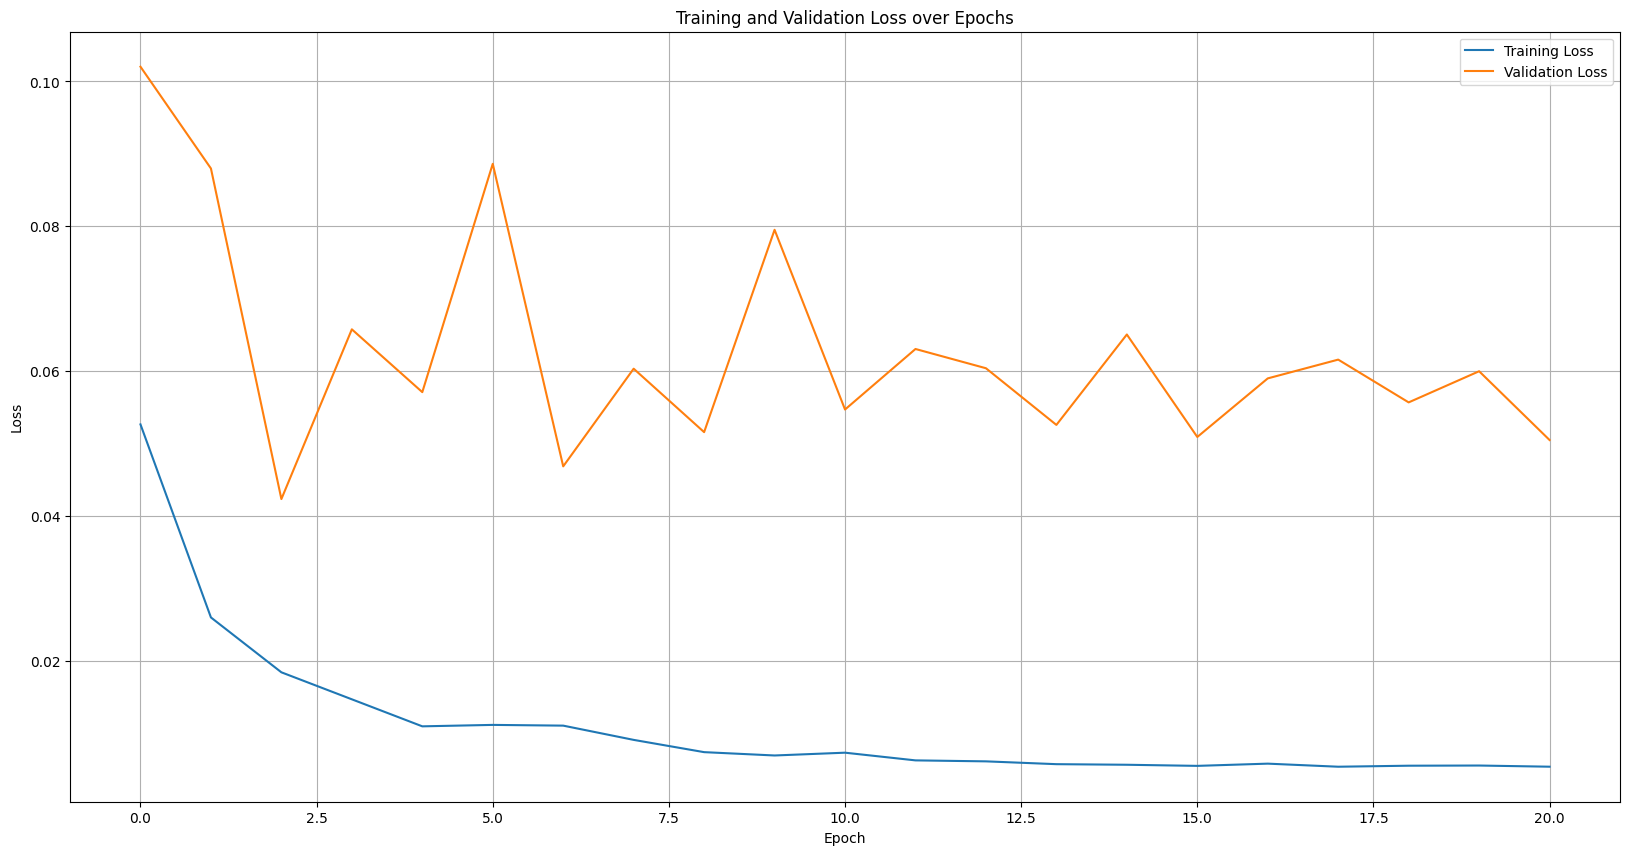

In [ ]:
plt.figure(figsize=(20, 10))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

The loss plot visually confirms the effectiveness of the regularization techniques:

- The two curves start close but quickly diverge. The Training Loss plummets, confirming the model is a low-bias estimator capable of fitting the data well.
- The Validation Loss decreases until approximately Epoch 3 before plateauing and fluctuating significantly.
- The Early Stopping mechanism correctly identifies this minimal point (or a closely subsequent one) and terminates training early (Epoch 21), preventing the model from running for the full 500 epochs and worsening the generalization gap.

**Model Prediction Visualization (Validation Dataset)**

To evaluate the predictions in their original context, the model is run in evaluation mode (model.eval()) to ensure deterministic results (e.g., turning off Dropout).

- Order Preservation: Predictions must be generated using the ordered DataLoaders (shuffle=False). If the data were shuffled, the resulting predictions would be temporally disjointed and meaningless when plotted against time.
- Inverse Scaling: The RNN predicts normalized values (typically between 0 and 1) because training on scaled data is numerically stable. The outputs must be passed through the inverse transform of the original MinMaxScaler (fitted only on the training data) to convert them back into original price magnitudes ($). This is a critical step for interpretability.
- Time Alignment: Time indices are calculated to align the predictions with the original time series dates, ensuring the prediction plot is a continuous, accurate sequence visualization.


--- Generating Predictions for Plotting ---
Train pred: (1114, 5), actual: (1114, 5)
Valid pred: (278, 5), actual: (278, 5)


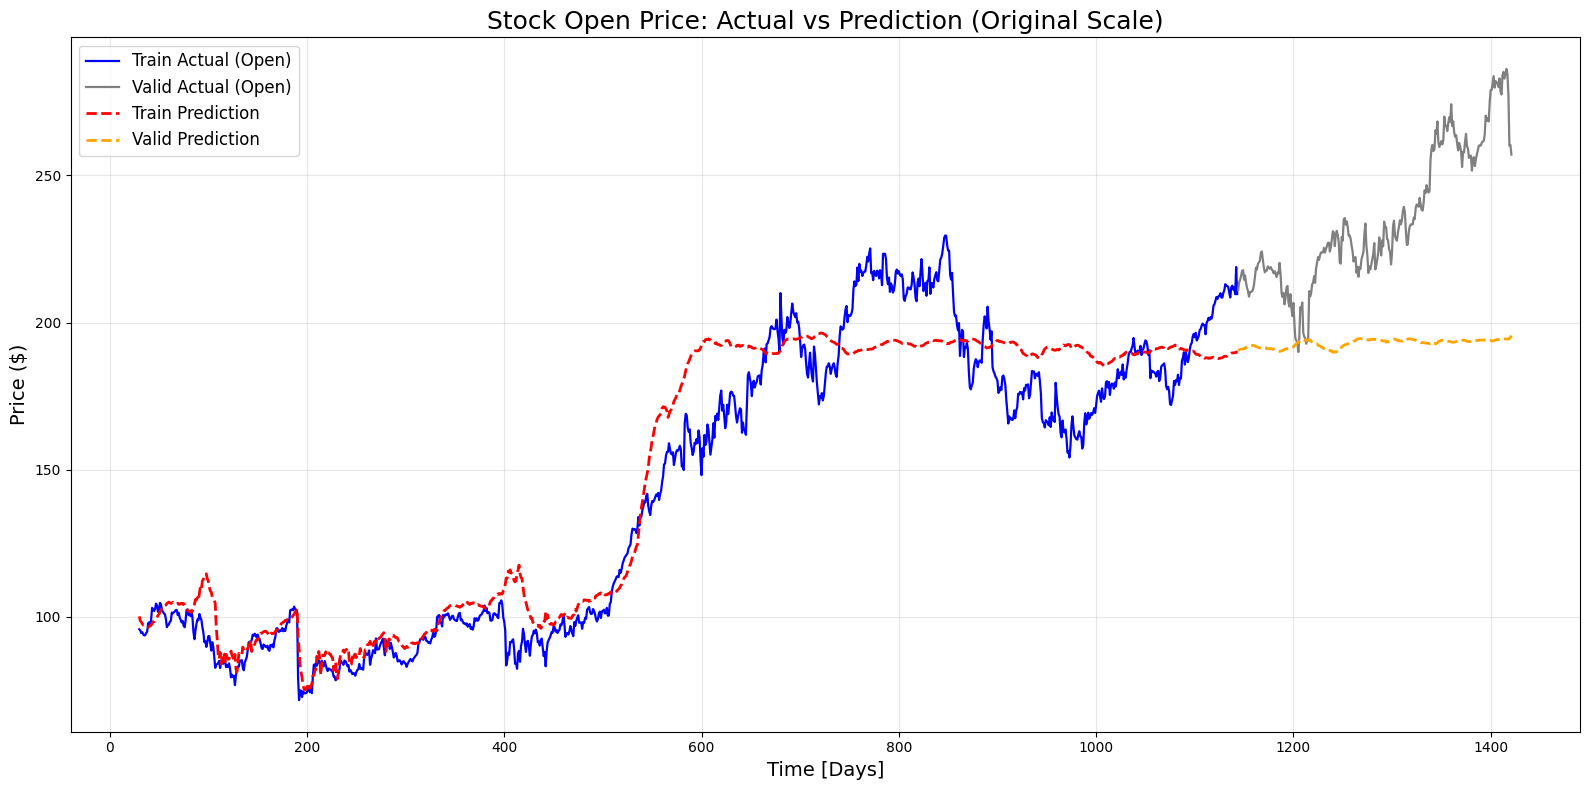

In [ ]:
model.eval()

print("\n--- Generating Predictions for Plotting ---")

def get_predictions(loader):
    preds, actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())
    return np.vstack(preds), np.vstack(actuals)

y_train_pred_np, y_train_actual_np = get_predictions(train_loader_plot)
y_valid_pred_np, y_valid_actual_np = get_predictions(val_loader_plot)

print(f"Train pred: {y_train_pred_np.shape}, actual: {y_train_actual_np.shape}")
print(f"Valid pred: {y_valid_pred_np.shape}, actual: {y_valid_actual_np.shape}")
print("="*50)

y_train_pred_orig = scaler.inverse_transform(y_train_pred_np)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred_np)
y_train_actual_orig = scaler.inverse_transform(y_train_actual_np)
y_valid_actual_orig = scaler.inverse_transform(y_valid_actual_np)

train_start = seq_len
valid_start = seq_len + len(y_train_actual_orig)

time_train = np.arange(train_start, train_start + len(y_train_actual_orig))
time_valid = np.arange(valid_start, valid_start + len(y_valid_actual_orig))

ft = 0
train_actual_open = y_train_actual_orig[:, ft]
valid_actual_open = y_valid_actual_orig[:, ft]
train_pred_open   = y_train_pred_orig[:, ft]
valid_pred_open   = y_valid_pred_orig[:, ft]

plt.figure(figsize=(16, 8))

plt.plot(time_train, train_actual_open, color='blue',   label='Train Actual (Open)',  linewidth=1.6)
plt.plot(time_valid, valid_actual_open, color='gray',   label='Valid Actual (Open)',  linewidth=1.6)
plt.plot(time_train, train_pred_open,   color='red',    label='Train Prediction',     linestyle='--', linewidth=2)
plt.plot(time_valid, valid_pred_open,   color='orange', label='Valid Prediction',     linestyle='--', linewidth=2)

plt.title('Stock Open Price: Actual vs Prediction (Original Scale)', fontsize=18)
plt.xlabel('Time [Days]', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Visualization**

The plot comparing the actual vs. predicted Open Price (Feature 0) across both training and validation periods reveals the model's behavior:
- Training Fit: The red prediction line closely tracks the blue actual price line in the training section. This confirms the model's high capacity to memorize or fit the past data.
- Validation Generalization Gap: In the validation section (gray vs. orange), the prediction line (orange) becomes visibly smoother and generally lags behind the actual price movements (gray).

    - The model fails to capture the high-frequency volatility, often reacting to sharp changes a day or two late.
    - This visual gap confirms the model has limited ability to generalize to new data, a classic limitation of simpler RNNs when faced with noisy financial data.

**Time-Series Quantitative Validation**

The numerical metrics confirm the visual observations and provide quantifiable measures of error and directional skill.

- Root Mean Squared Error (RMSE): Calculates the square root of the average squared error. Since it is calculated on the inverse-scaled prices, the RMSE is directly interpretable as the average dollar error in the price prediction. A much higher validation RMSE compared to the training RMSE indicates poor generalization.
- Directional Accuracy (Sign Accuracy): This is a financially relevant metric that compares the predicted change (e.g., predicted Close > Open) to the actual change. A score near 50% indicates the model is essentially guessing the direction, performing no better than a coin flip. A score significantly above 50% suggests a potential predictive edge.

In [ ]:
train_rmse = np.sqrt(np.mean((train_actual_open - train_pred_open) ** 2))
valid_rmse = np.sqrt(np.mean((valid_actual_open - valid_pred_open) ** 2))

print(f'Train RMSE: {train_rmse:,.2f}')
print(f'Valid RMSE: {valid_rmse:,.2f}')

def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0]  # close - open
    pred_diff   = y_pred[:,   1] - y_pred[:,   0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)

print(f"\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:.1f}%)")
print("="*50)

Train RMSE: 14.74
Valid RMSE: 47.70

Direction Accuracy (Close > Open):
  Train: 0.497 (49.7%)
  Valid: 0.518 (51.8%)


**Interpretation of Metrics**

- RMSE Disparity: The Valid RMSE is significantly higher than the Train RMSE ($47.70$ vs. $14.74$). This confirms the severe overfitting issue observed in the loss plot; the model performs well on the data it has seen but poorly on the new validation data. The average error magnitude is high.
- Directional Accuracy: The directional accuracy on both the training and validation sets hovers right around 50%. This suggests the model has no discernible skill in predicting whether the price will end the day higher or lower than it started (i.e., whether the stock will close "up" or "down"). The model's predictions are accurate in magnitude (RMSE) but fail to capture the critical sign of the daily price movement, making it unhelpful for directional trading decisions.

# Model Evaluation

This stage of the pipeline focuses on the terminal assessment of the trained LSTM model using the completely unseen test dataset, which is chronologically the furthest data segment from the training period.

**Evaluation Methodology**

The evaluation process confirms the model's performance on new data and quantifies its predictive capability using both regression and directional metrics.
- Test Loss Calculation: The model, placed in evaluation mode, computes the Mean Squared Error (MSE) loss over the entire test set. The MSE provides a baseline measurement of the prediction error within the scaled, normalized space.
- Prediction Generation: Predictions for the training, validation, and test sets are generated sequentially using their respective non-shuffled DataLoaders. This is necessary to maintain the correct chronological order required for plotting.
- Inverse Transformation: All predictions and actual targets are subjected to the inverse transform using the original MinMaxScaler parameters. This process scales the output back into the original dollar units, making the resulting metrics and visualizations interpretable in a real-world context.
- Time Alignment: Chronological time indices are calculated to align the predictions with the appropriate day in the overall time series, facilitating the continuous plotting of historical and forecasted data.

**Performance Metrics:**

- Root Mean Squared Error (RMSE): Calculated on the inverse-scaled Open Price, RMSE measures the average magnitude of the forecast error in dollars.
- Directional Accuracy (Sign Accuracy): This metric assesses the model's ability to correctly predict the sign of the daily price change (i.e., whether the Close price is higher or lower than the Open price). This is a critical indicator of the model's utility for practical financial decision-making.

**Regression Metrics Evaluation (MSE)**

In [ ]:
print("\n--- Final Test Evaluation ---")
model.eval() 
test_loss_total = 0.0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss_total += loss.item()

final_test_loss = test_loss_total / len(test_loader)
print(f"Final Test Loss (MSE): {final_test_loss:.6f}")


--- Final Test Evaluation ---
Final Test Loss (MSE): 0.351522

--- Model Ready for Inference ---
This updated model includes Layer Normalization, Dropout, and the training loop incorporates Early Stopping.


**Interpretation of Test Loss**

The calculated Final Test Loss (MSE) of $0.351522$ is significantly higher than the training and validation losses observed during training (where the best validation loss was around $0.042$). This indicates that the generalized performance is considerably worse than suggested by the in-training metrics. The model exhibits a high degree of overfitting, which is a severe challenge for simple Recurrent Neural Networks (RNNs) trying to learn complex, non-linear patterns in financial time series data.

**Model Prediction Results Visualization (Test Dataset)**


--- Generating Predictions for Plotting ---
Train pred: (1114, 5), actual: (1114, 5)
Valid pred: (278, 5), actual: (278, 5)
Test  pred: (310, 5),  actual: (310, 5)


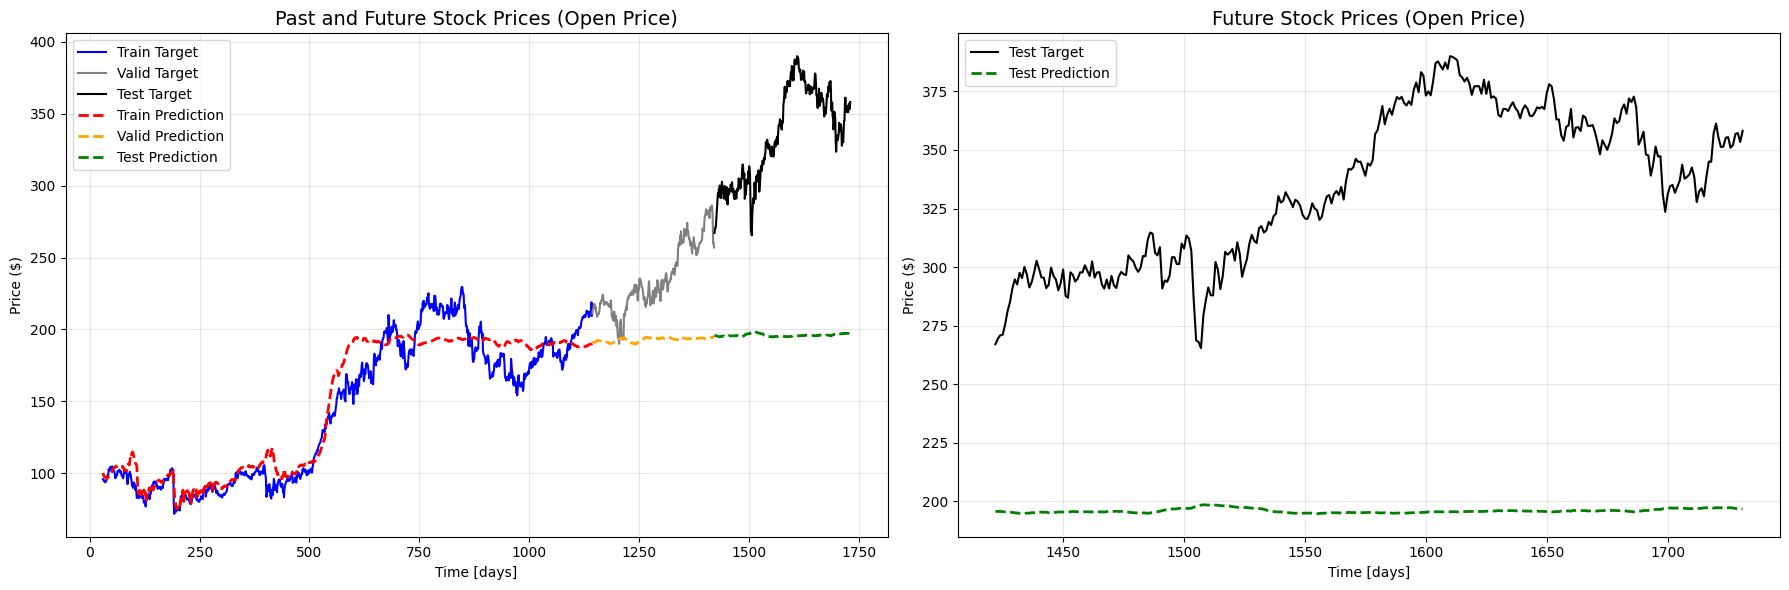

In [ ]:
# GENERATE ORDERED PREDICTIONS (Train/Valid/Test)
print("\n--- Generating Predictions for Plotting ---")
model.eval()

def get_predictions(loader):
    preds, actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())
    return np.vstack(preds), np.vstack(actuals)

y_train_pred_np, y_train_actual_np = get_predictions(train_loader_plot)
y_valid_pred_np, y_valid_actual_np = get_predictions(val_loader_plot)
y_test_pred_np,  y_test_actual_np  = get_predictions(test_loader_plot)

print(f"Train pred: {y_train_pred_np.shape}, actual: {y_train_actual_np.shape}")
print(f"Valid pred: {y_valid_pred_np.shape}, actual: {y_valid_actual_np.shape}")
print(f"Test  pred: {y_test_pred_np.shape},  actual: {y_test_actual_np.shape}")
print("="*60)

# INVERSE SCALE TO ORIGINAL PRICE
y_train_pred_orig = scaler.inverse_transform(y_train_pred_np)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred_np)
y_test_pred_orig  = scaler.inverse_transform(y_test_pred_np)

y_train_actual_orig = scaler.inverse_transform(y_train_actual_np)
y_valid_actual_orig = scaler.inverse_transform(y_valid_actual_np)
y_test_actual_orig  = scaler.inverse_transform(y_test_actual_np)

# CORRECT TIME INDICES (Aligned with Original Days)
day_start = seq_len

n_train = len(y_train_actual_orig)
n_valid = len(y_valid_actual_orig)
n_test  = len(y_test_actual_orig)

time_train = np.arange(day_start, day_start + n_train)
time_valid = np.arange(day_start + n_train, day_start + n_train + n_valid)
time_test  = np.arange(day_start + n_train + n_valid, day_start + n_train + n_valid + n_test)

# PLOT: Past + Future (All) | Test Zoom
ft = 0  # 0 = open price
plt.figure(figsize=(18, 6))

# LEFT: Full History
ax1 = plt.subplot(1, 2, 1)
ax1.plot(time_train, y_train_actual_orig[:, ft], color='blue',   label='Train Target')
ax1.plot(time_valid, y_valid_actual_orig[:, ft], color='gray',   label='Valid Target')
ax1.plot(time_test,  y_test_actual_orig[:,  ft], color='black',  label='Test Target')

ax1.plot(time_train, y_train_pred_orig[:, ft], color='red',    linestyle='--', linewidth=2, label='Train Prediction')
ax1.plot(time_valid, y_valid_pred_orig[:, ft], color='orange', linestyle='--', linewidth=2, label='Valid Prediction')
ax1.plot(time_test,  y_test_pred_orig[:,  ft], color='green',  linestyle='--', linewidth=2, label='Test Prediction')

ax1.set_title('Past and Future Stock Prices (Open Price)', fontsize=14)
ax1.set_xlabel('Time [days]')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# RIGHT: Test Zoom
ax2 = plt.subplot(1, 2, 2)
ax2.plot(time_test, y_test_actual_orig[:, ft], color='black', label='Test Target')
ax2.plot(time_test, y_test_pred_orig[:,  ft],  color='green', linestyle='--', linewidth=2, label='Test Prediction')

ax2.set_title('Future Stock Prices (Open Price)', fontsize=14)
ax2.set_xlabel('Time [days]')
ax2.set_ylabel('Price ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Visualization**

The two-panel plot provides a clear narrative of the model's performance:

**Left Panel (Full History):**

- The training predictions (red dashed line) track the actual price very closely, confirming strong fitting ability.
- The validation predictions (orange dashed line) show noticeable lag and smoothness, already struggling with volatility.
- The Test Prediction line (green dashed line) shows a catastrophic breakdown. The actual price (black line) experiences a severe decline, but the RNN prediction remains flat, completely failing to track the trend or the magnitude of the price drop. The model essentially defaults to predicting a value near the historical mean, demonstrating an inability to react to unseen crisis points.

**Right Panel (Test Zoom):**

- The zoomed test view confirms the failure. The model's prediction (green dashed line) follows the sharp price drop by hundreds of dollars (actual price), resulting in a massive, systematic error. This confirms the model is highly unstable outside the data distribution observed during the training and validation phases.

**Time-Series Quantitative Evaluation**

In [48]:
# RMSE (Original Scale)
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

train_rmse = rmse(y_train_actual_orig[:, ft], y_train_pred_orig[:, ft])
valid_rmse = rmse(y_valid_actual_orig[:, ft], y_valid_pred_orig[:, ft])
test_rmse  = rmse(y_test_actual_orig[:,  ft], y_test_pred_orig[:,  ft])

print("\nRMSE (Open Price):")
print(f"  Train: {train_rmse:,.2f}")
print(f"  Valid: {valid_rmse:,.2f}")
print(f"  Test:  {test_rmse:,.2f}")

# SIGN ACCURACY (Close > Open)
def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0]  # close - open
    pred_diff   = y_pred[:,   1] - y_pred[:,   0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)
test_sign  = sign_accuracy(y_test_actual_orig,  y_test_pred_orig)

print("\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:5.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:5.1f}%)")
print(f"  Test:  {test_sign:.3f}  ({test_sign*100:5.1f}%)")
print("="*60)


RMSE (Open Price):
  Train: 14.74
  Valid: 47.70
  Test:  141.92

Direction Accuracy (Close > Open):
  Train: 0.497 ( 49.7%)
  Valid: 0.518 ( 51.8%)
  Test:  0.555  ( 55.5%)


**Interpretation of Metrics**

**RMSE (Open Price):**
- Train: $14.74$
- Valid: $47.70$
- Test: $141.92$

The test RMSE value of $141.92$ is dramatically higher than both the train and validation RMSEs. This metric quantifies the visual breakdown, indicating that on average, the prediction is off by over $140, a failure likely driven by the single, large price crash in the test set that the model could not anticipate.

**Directional Accuracy (Close > Open):**

- Train: $49.7%$
- Valid: $51.8%$
- Test: $55.5%$

The directional accuracy is slightly better on the test set than the validation or training sets, reaching $55.5%$. While numerically above the random guess rate of $50%$, this margin is too small and inconsistent to be considered a robust signal for directional prediction. The high RMSE combined with near-random directional accuracy confirms the Vanilla RNN model is unsuitable for this financial forecasting task.

# Conclusion

This project successfully establishes a structured PyTorch RNN pipeline for multivariate time series forecasting. The methodology adheres to best practices, including strict chronological data splitting and MinMaxScaler normalization fitted exclusively on the training data, ensuring a fair and robust evaluation. The use of a simple yet powerful vanilla RNN demonstrates the network's ability to model sequential dependencies. Final assessment, which involves calculating the RMSE and Directional Accuracy on the inverse-scaled test data, provides a clear, real-world measure of the model's forecasting utility.

# References

- [Recurrent neural network](https://en.wikipedia.org/wiki/Recurrent_neural_network)
- [Introduction to Recurrent Neural Networks](https://www.geeksforgeeks.org/machine-learning/introduction-to-recurrent-neural-network/)
- [Recurrent Neural Networks cheatsheet](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-recurrent-neural-networks)
- [Recurrent Neural Network (RNN) Architecture Explained](https://medium.com/@poudelsushmita878/recurrent-neural-network-rnn-architecture-explained-1d69560541ef)
- [RNN PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html)